In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading Data

In [2]:
# this is the latest df_main
df_main = pd.read_csv("df_main_final.csv")

In [3]:
df_main

,fips,Staffed_Beds,Total_Discharges,Patient_Days,Gross_Patient_Revenue,Hospitals,Local_Hospital,ADI_NATRANK,ADI_STATERNK,Value_education,...,pop_sex_female_age_65_and_above,pop_sex_male_age_0_to_18,pop_sex_male_age_18_to_65,pop_sex_male_age_65_and_above,pct_pop_sex_female_age_0_to_18,pct_pop_sex_female_age_18_to_65,pct_pop_sex_female_age_65_and_above,pct_pop_sex_male_age_0_to_18,pct_pop_sex_male_age_18_to_65,pct_pop_sex_male_age_65_and_above
0,1001,77.0,3049.0,15984.0,250284.0,1.0,1,66.977778,4.355556,21.714286,...,4807,6765,16604,3683,11.463182,2.703566e+05,8.639623,12.158738,29.842378,6.619459
1,1003,301.0,18080.0,78361.0,2481966.0,3.0,1,51.534483,2.655172,21.928571,...,24115,23873,61415,20601,10.591464,1.052924e+06,11.047282,10.936420,28.134720,9.437488
2,1005,47.0,1055.0,4571.0,76099.0,1.0,1,90.900000,7.950000,22.285714,...,2704,2589,8494,2073,10.521058,1.189912e+05,10.804763,10.345241,33.940702,8.283385
3,1007,156.0,229.0,1053.0,31288.0,1.0,1,83.411765,6.647059,21.571429,...,2059,2509,7896,1617,9.274157,1.064437e+05,9.202647,11.213908,35.290962,7.227138
4,1009,0.0,0.0,0.0,0.0,0.0,0,72.325581,4.906977,21.571429,...,5747,6873,17169,4635,11.252705,2.780570e+05,9.950653,11.900268,29.727297,8.025280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3119,56037,58.0,1279.0,4742.0,207720.0,2.0,1,54.088235,6.147059,22.360714,...,2767,5805,14010,2525,12.682229,2.082663e+05,6.382636,13.390386,32.316848,5.824414
3120,56039,121.0,1711.0,5932.0,273723.0,1.0,1,6.473684,1.000000,22.496429,...,1773,2394,8233,1708,7.698235,1.120697e+05,7.591198,10.250043,35.250043,7.312895
3121,56041,32.0,803.0,1627.0,105109.0,1.0,1,57.058824,7.117647,22.500000,...,1405,2989,5863,1463,14.081672,9.838124e+04,6.896043,14.670658,28.776872,7.180720
3122,56043,0.0,0.0,0.0,0.0,0.0,0,59.555556,7.777778,22.710714,...,902,966,2256,814,11.622337,3.799210e+04,11.370225,12.176982,28.438170,10.260935


In [4]:
print(list(df_main.columns))

['fips', 'Staffed_Beds', 'Total_Discharges', 'Patient_Days', 'Gross_Patient_Revenue', 'Hospitals', 'Local_Hospital', 'ADI_NATRANK', 'ADI_STATERNK', 'Value_education', 'Value_poverty', 'Value_unemployment', 'pct_pop_commute_departure_0000_to_0459', 'pct_pop_commute_departure_0500_to_0529', 'pct_pop_commute_departure_0530_to_0559', 'pct_pop_commute_departure_0600_to_0629', 'pct_pop_commute_departure_0630_to_0659', 'pct_pop_commute_departure_0700_to_0729', 'pct_pop_commute_departure_0730_to_0759', 'pct_pop_commute_departure_0800_to_0829', 'pct_pop_commute_departure_0830_to_0859', 'pct_pop_commute_departure_0900_to_0959', 'pct_pop_commute_departure_1000_to_1059', 'pct_pop_commute_departure_1100_to_1159', 'pct_pop_commute_departure_1200_to_1559', 'pct_pop_commute_departure_1600_to_2359', 'pct_pop_commute_travel_time_10_to_14_min', 'pct_pop_commute_travel_time_15_to_19_min', 'pct_pop_commute_travel_time_20_to_24_min', 'pct_pop_commute_travel_time_25_to_29_min', 'pct_pop_commute_travel_time_3

In [5]:
# fill na with 0 
df_main['avg_death_rate'] = df_main['avg_death_rate'].fillna(0)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [7]:
X = df_main.drop(columns=['avg_death_rate'])
y = df_main['avg_death_rate']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Model Fitting - Random forest(regression)

### using r2 to choose best parameters

In [36]:
# Fitting Random Forest Regression to the dataset
# import the regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# used to cache results
from tempfile import mkdtemp
from shutil import rmtree
from joblib import Memory
# print(__doc__)
cachedir = mkdtemp()
memory = Memory(location=cachedir, verbose=10)

pipeline = Pipeline([
    ('clf', None)
],
memory=memory
)


param_grid = [
    {
#         'reduce_dim': None,
        'clf':[RandomForestRegressor(random_state=0)],
        'clf__n_estimators':[5,10,50,80,100],
        'clf__max_depth':[10,50,80]
    }
]

grid1 = GridSearchCV(pipeline, cv=3, n_jobs=-1, param_grid=param_grid, scoring='r2',pre_dispatch=3) #'neg_mean_squared_error'
grid1.fit(X_train, y_train)
rmtree(cachedir)

In [37]:
results1 = pd.DataFrame(grid1.cv_results_).sort_values(by=['mean_test_score'], ascending=False)
results1 = results1.reset_index(drop=True)
results1.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf,param_clf__max_depth,param_clf__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,12.159211,0.185031,0.008009,0.000808,"RandomForestRegressor(max_depth=10, random_sta...",10,100,"{'clf': RandomForestRegressor(max_depth=10, ra...",0.020932,0.093701,0.009975,0.041536,0.037156,1
1,9.676469,0.147884,0.007679,0.000456,"RandomForestRegressor(max_depth=10, random_sta...",10,80,"{'clf': RandomForestRegressor(max_depth=10, ra...",0.016563,0.086063,0.008362,0.036996,0.034857,2
2,6.009489,0.079734,0.005002,0.000005,"RandomForestRegressor(max_depth=10, random_sta...",10,50,"{'clf': RandomForestRegressor(max_depth=10, ra...",0.016111,0.075643,0.010486,0.034080,0.029479,3
3,18.661311,0.563194,0.015005,0.000025,"RandomForestRegressor(max_depth=10, random_sta...",50,100,"{'clf': RandomForestRegressor(max_depth=10, ra...",-0.001558,0.079178,-0.004465,0.024385,0.038763,4
4,18.631092,0.517087,0.014335,0.000470,"RandomForestRegressor(max_depth=10, random_sta...",80,100,"{'clf': RandomForestRegressor(max_depth=10, ra...",-0.001558,0.079178,-0.004465,0.024385,0.038763,4


In [38]:
print(grid1.best_params_)

{'clf': RandomForestRegressor(max_depth=10, random_state=0), 'clf__max_depth': 10, 'clf__n_estimators': 100}


In [51]:
# use best parameter
regressor = RandomForestRegressor(n_estimators = 100,max_depth = 10,random_state=0)
regressor.fit(X_train,y_train)
y_pred = regressor.predict(X_test)

In [52]:
from sklearn import metrics
print('r2:', metrics.r2_score(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:',
      np.sqrt(metrics.mean_squared_error(y_test, y_pred)))


r2: 0.08544408790666147
Mean Squared Error: 0.0004714862604021661
Root Mean Squared Error: 0.021713734372561667


In [53]:
# Get numerical feature importances
importances = list(regressor.feature_importances_)
# List of tuples with variable and importance
# print(importances)

# Saving feature names for later use
feature_list = list(X.columns)

feature_importances = [(feature, round(importance, 2)) for feature, importance in zip(feature_list, importances)]
# Sort the feature importances by most important first
feature_importances = sorted(feature_importances, key = lambda x: x[1], reverse = True)
print(feature_importances[0:10])

[('pop_race_black', 0.03), ('pop_commute_travel_time_60_to_89_min', 0.02), ('pop_below_100_pct_poverty_level', 0.02), ('pct_pop_sex_male_age_0_to_18', 0.02), ('fips', 0.01), ('ADI_NATRANK', 0.01), ('Value_education', 0.01), ('Value_unemployment', 0.01), ('pct_pop_commute_departure_0830_to_0859', 0.01), ('pct_pop_commute_travel_time_30_to_34_min', 0.01)]


### using neg_mean_squared_error to choose best parameters

In [42]:
# Fitting Random Forest Regression to the dataset
# import the regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# used to cache results
from tempfile import mkdtemp
from shutil import rmtree
from joblib import Memory
# print(__doc__)
cachedir = mkdtemp()
memory = Memory(location=cachedir, verbose=10)

pipeline = Pipeline([
    ('clf', None)
],
memory=memory
)


param_grid = [
    {
#         'reduce_dim': None,
        'clf':[RandomForestRegressor(random_state=0)],
        'clf__n_estimators':[5,10,50,80,100],
        'clf__max_depth':[10,50,80]
    }
]

grid2 = GridSearchCV(pipeline, cv=3, n_jobs=-1, param_grid=param_grid, scoring='neg_mean_squared_error',pre_dispatch=3) 
grid2.fit(X_train, y_train)
rmtree(cachedir)

In [43]:
results2 = pd.DataFrame(grid2.cv_results_).sort_values(by=['mean_test_score'], ascending=False)
results2 = results2.reset_index(drop=True)
results2.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf,param_clf__max_depth,param_clf__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,11.990872,0.176797,0.008339,0.000477,"RandomForestRegressor(max_depth=10, random_sta...",10,100,"{'clf': RandomForestRegressor(max_depth=10, ra...",-0.000455,-0.000416,-0.000531,-0.000467,0.000048,1
1,9.634081,0.153344,0.006653,0.000466,"RandomForestRegressor(max_depth=10, random_sta...",10,80,"{'clf': RandomForestRegressor(max_depth=10, ra...",-0.000457,-0.000420,-0.000532,-0.000470,0.000047,2
2,5.932096,0.064505,0.004652,0.000486,"RandomForestRegressor(max_depth=10, random_sta...",10,50,"{'clf': RandomForestRegressor(max_depth=10, ra...",-0.000457,-0.000424,-0.000531,-0.000471,0.000045,3
3,18.833745,0.589082,0.014687,0.000494,"RandomForestRegressor(max_depth=10, random_sta...",50,100,"{'clf': RandomForestRegressor(max_depth=10, ra...",-0.000466,-0.000423,-0.000539,-0.000476,0.000048,4
4,19.014934,0.546312,0.014677,0.000481,"RandomForestRegressor(max_depth=10, random_sta...",80,100,"{'clf': RandomForestRegressor(max_depth=10, ra...",-0.000466,-0.000423,-0.000539,-0.000476,0.000048,4


In [44]:
print(grid2.best_params_)

{'clf': RandomForestRegressor(max_depth=10, random_state=0), 'clf__max_depth': 10, 'clf__n_estimators': 100}


In [45]:
# use best parameter
regressor = RandomForestRegressor(n_estimators = 10,max_depth=10,random_state=0)
regressor.fit(X_train,y_train)
y_pred = regressor.predict(X_test)

print('r2:', metrics.r2_score(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:',
      np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

r2: 0.0015872049705163427
Mean Squared Error: 0.0005147174807373424
Root Mean Squared Error: 0.022687385938828266


In [50]:
# Get numerical feature importances
importances = list(regressor.feature_importances_)
# List of tuples with variable and importance
# print(importances)

# Saving feature names for later use
feature_list = list(X.columns)

feature_importances = [(feature, round(importance, 2)) for feature, importance in zip(feature_list, importances)]
# Sort the feature importances by most important first
feature_importances = sorted(feature_importances, key = lambda x: x[1], reverse = True)
print(feature_importances[0:10])

[('pct_pop_sex_male_age_0_to_18', 0.03), ('pct_pop_commute_travel_time_under_5_min', 0.02), ('pct_pop_works_outside_state_of_residence', 0.02), ('pop_works_in_state_different_county_of_residence', 0.02), ('pct_pop_race_native_american', 0.02), ('pop_race_black', 0.02), ('pop_below_100_pct_poverty_level', 0.02), ('households_with_computing_devices_none', 0.02), ('households_with_no_internet_access', 0.02), ('pct_pop_adult_education_less_than_high_school', 0.02)]


## Feature selection, then model fitting

### use the best model chose by r2

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.feature_selection import RFECV

In [14]:
# Create the RFE object and compute a cross-validated score.
rf = RandomForestRegressor(max_depth = 10,random_state=0)

rfecv = RFECV(estimator=rf,         
              step=1,               
              cv=KFold(3),     
              scoring='r2',  
              verbose = 0,    
              n_jobs = -1
              )
X_RFECV = rfecv.fit_transform(X_train,y_train)

RFECV results——————————————————————————————————————————————————
Optimal number of features : 186
Ranking of features : [1, 1, 40, 79, 57, 67, 88, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 75, 38, 1, 1, 1, 4, 1, 1, 17, 1, 51, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 6, 25, 1, 16, 78, 10, 14, 43, 61, 1, 19, 34, 52, 1, 48, 1, 1, 1, 1, 1, 9, 1, 1, 1, 87, 72, 86, 60, 33, 1, 1, 1, 55, 1, 1, 1, 1, 1, 76, 80, 46, 56, 1, 30, 1, 1, 1, 1, 12, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 81, 1, 27, 1, 1, 63, 49, 1, 83, 1, 1, 1, 74, 41, 29, 1, 65, 1, 47, 1, 36, 7, 69, 1, 1, 1, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 24, 1, 1, 1, 1, 89, 1, 66, 62, 85, 21, 42, 1, 2, 26, 1, 22, 53, 3, 1, 1, 1, 23, 59, 1, 1, 1, 20, 45, 35, 77, 8, 1, 1, 1, 1, 1, 28, 39, 37, 70, 1, 18, 58, 73, 82, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 32, 1, 1, 1, 1, 11, 1, 1, 1, 1, 1, 1, 1, 84, 1, 1, 64, 71, 68, 1, 31, 1, 15, 13, 54, 50, 

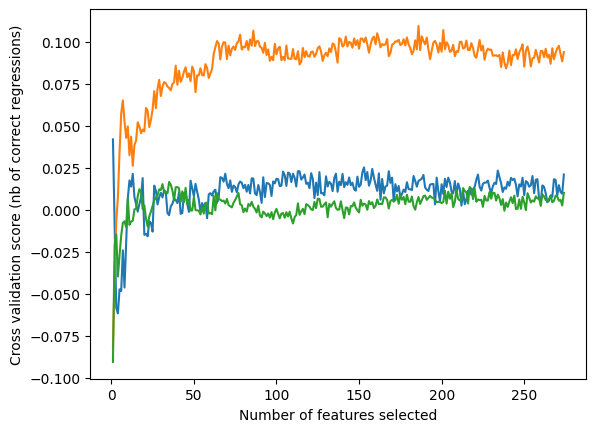

In [13]:
print("RFECV results——————————————————————————————————————————————————")
print("Optimal number of features : %d" % rfecv.n_features_)
# print("Optimal features : %d" % rfecv.feature_names_in_)
print("Ranking of features : %s" % list(rfecv.ranking_))


# Plot number of features VS. cross-validation scores
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score (nb of correct regressions)")
plt.plot(range(1, len(rfecv.grid_scores_) + 1), rfecv.grid_scores_)
plt.show()

In [20]:
ranking = list(rfecv.ranking_)
ind = []
for i in range(0,len(ranking)):
    if ranking[i]==1:
        ind.append(i)
X_new = X.iloc[:,ind]

In [27]:
X_new

,fips,Staffed_Beds,ADI_NATRANK,ADI_STATERNK,Value_education,Value_poverty,Value_unemployment,pct_pop_commute_departure_0000_to_0459,pct_pop_commute_departure_0500_to_0529,pct_pop_commute_departure_0530_to_0559,...,pop_adult_education_high_school,pop_adult_education_less_than_high_school,pop_veterans_female,pop_sex_female_age_0_to_18,pop_sex_male_age_65_and_above,pct_pop_sex_female_age_0_to_18,pct_pop_sex_female_age_65_and_above,pct_pop_sex_male_age_0_to_18,pct_pop_sex_male_age_18_to_65,pct_pop_sex_male_age_65_and_above
0,1001,77.0,66.977778,4.355556,21.714286,10.400000,4.611538,2.571937,2.597099,1.583422,...,8819,2886,542,6378,3683,11.463182,8.639623,12.158738,29.842378,6.619459
1,1003,301.0,51.534483,2.655172,21.928571,10.861538,4.830769,1.623536,1.502137,2.028503,...,29636,10250,1573,23120,20601,10.591464,11.047282,10.936420,28.134720,9.437488
2,1005,47.0,90.900000,7.950000,22.285714,23.053846,9.800000,2.825062,2.105810,2.153760,...,4525,3131,107,2633,2073,10.521058,10.804763,10.345241,33.940702,8.283385
3,1007,156.0,83.411765,6.647059,21.571429,18.446154,8.814815,1.903996,3.459372,3.495128,...,5442,2189,63,2075,1617,9.274157,9.202647,11.213908,35.290962,7.227138
4,1009,0.0,72.325581,4.906977,21.571429,10.600000,4.480769,2.829192,2.711454,2.765129,...,9757,4494,218,6499,4635,11.252705,9.950653,11.900268,29.727297,8.025280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3119,56037,58.0,54.088235,6.147059,22.360714,8.323077,4.438462,3.363167,2.779572,3.990589,...,7298,1656,223,5498,2525,12.682229,6.382636,13.390386,32.316848,5.824414
3120,56039,121.0,6.473684,1.000000,22.496429,12.092857,4.176923,0.787806,1.061826,1.704059,...,2278,871,98,1798,1708,7.698235,7.591198,10.250043,35.250043,7.312895
3121,56041,32.0,57.058824,7.117647,22.500000,9.230769,4.723077,3.357220,2.473741,4.211250,...,3960,664,74,2869,1463,14.081672,6.896043,14.670658,28.776872,7.180720
3122,56043,0.0,59.555556,7.777778,22.710714,16.021429,7.985185,1.991680,2.105130,1.853019,...,1021,308,23,922,814,11.622337,11.370225,12.176982,28.438170,10.260935


In [36]:
print(list(X_new.columns))

['fips', 'Staffed_Beds', 'ADI_NATRANK', 'ADI_STATERNK', 'Value_education', 'Value_poverty', 'Value_unemployment', 'pct_pop_commute_departure_0000_to_0459', 'pct_pop_commute_departure_0500_to_0529', 'pct_pop_commute_departure_0530_to_0559', 'pct_pop_commute_departure_0600_to_0629', 'pct_pop_commute_departure_0630_to_0659', 'pct_pop_commute_departure_0700_to_0729', 'pct_pop_commute_departure_0730_to_0759', 'pct_pop_commute_departure_0800_to_0829', 'pct_pop_commute_departure_0830_to_0859', 'pct_pop_commute_departure_0900_to_0959', 'pct_pop_commute_departure_1000_to_1059', 'pct_pop_commute_departure_1100_to_1159', 'pct_pop_commute_departure_1200_to_1559', 'pct_pop_commute_departure_1600_to_2359', 'pct_pop_commute_travel_time_10_to_14_min', 'pct_pop_commute_travel_time_15_to_19_min', 'pct_pop_commute_travel_time_20_to_24_min', 'pct_pop_commute_travel_time_25_to_29_min', 'pct_pop_commute_travel_time_30_to_34_min', 'pct_pop_commute_travel_time_35_to_39_min', 'pct_pop_commute_travel_time_40_to

In [22]:
y = df_main['avg_death_rate']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [25]:
# Fitting Random Forest Regression to the dataset
# import the regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# used to cache results
from tempfile import mkdtemp
from shutil import rmtree
from joblib import Memory
# print(__doc__)
cachedir = mkdtemp()
memory = Memory(location=cachedir, verbose=10)

pipeline = Pipeline([
    ('clf', None)
],
memory=memory
)


param_grid = [
    {
#         'reduce_dim': None,,
        'clf':[RandomForestRegressor(max_depth = 10,random_state=0)],
        'clf__n_estimators':[5,10,50,80,100]
#         'clf__max_depth':[10,50,80]
    }
]

grid3 = GridSearchCV(pipeline, cv=3, n_jobs=-1, param_grid=param_grid, scoring='r2',pre_dispatch=3) #'neg_mean_squared_error'
grid3.fit(X_train, y_train)
rmtree(cachedir)

In [26]:
results3 = pd.DataFrame(grid3.cv_results_).sort_values(by=['mean_test_score'], ascending=False)
results3 = results3.reset_index(drop=True)
results3.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf,param_clf__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,8.394115,0.132886,0.007674,0.000479,"RandomForestRegressor(max_depth=10, random_sta...",100,"{'clf': RandomForestRegressor(max_depth=10, ra...",0.010732,0.092177,0.003358,0.035423,0.040244,1
1,6.705806,0.106333,0.006329,0.000473,"RandomForestRegressor(max_depth=10, random_sta...",80,"{'clf': RandomForestRegressor(max_depth=10, ra...",0.010519,0.089133,0.003499,0.034384,0.038820,2
2,4.181023,0.052060,0.004670,0.000474,"RandomForestRegressor(max_depth=10, random_sta...",50,"{'clf': RandomForestRegressor(max_depth=10, ra...",0.015877,0.082065,0.005090,0.034344,0.034030,3
3,0.835065,0.007521,0.002001,0.000003,"RandomForestRegressor(max_depth=10, random_sta...",10,"{'clf': RandomForestRegressor(max_depth=10, ra...",-0.021098,0.042285,-0.031677,-0.003497,0.032660,4
4,0.416989,0.004935,0.001655,0.000463,"RandomForestRegressor(max_depth=10, random_sta...",5,"{'clf': RandomForestRegressor(max_depth=10, ra...",-0.055300,-0.026772,-0.072703,-0.051592,0.018934,5


In [28]:
print(grid3.best_params_)

{'clf': RandomForestRegressor(max_depth=10, random_state=0), 'clf__n_estimators': 100}


In [32]:
import sklearn.metrics as metrics

In [33]:
# use best parameter
regressor = RandomForestRegressor(n_estimators = 100,max_depth=10,random_state=0)
regressor.fit(X_train,y_train)
y_pred = regressor.predict(X_test)

print('r2:', metrics.r2_score(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:',
      np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

r2: 0.0934007704259282
Mean Squared Error: 0.00046738430617869
Root Mean Squared Error: 0.021619072740954686


In [34]:
# Get numerical feature importances
importances = list(regressor.feature_importances_)
# List of tuples with variable and importance
# print(importances)

# Saving feature names for later use
feature_list = list(X_new.columns)

feature_importances = [(feature, round(importance, 2)) for feature, importance in zip(feature_list, importances)]
# Sort the feature importances by most important first
feature_importances = sorted(feature_importances, key = lambda x: x[1], reverse = True)
print(feature_importances[0:20])

[('pop_race_black', 0.03), ('pop_commute_travel_time_60_to_89_min', 0.02), ('pop_below_100_pct_poverty_level', 0.02), ('pct_pop_sex_male_age_0_to_18', 0.02), ('fips', 0.01), ('ADI_NATRANK', 0.01), ('Value_education', 0.01), ('Value_unemployment', 0.01), ('pct_pop_commute_departure_0000_to_0459', 0.01), ('pct_pop_commute_departure_0800_to_0829', 0.01), ('pct_pop_commute_departure_0830_to_0859', 0.01), ('pct_pop_commute_travel_time_25_to_29_min', 0.01), ('pct_pop_commute_travel_time_30_to_34_min', 0.01), ('pct_pop_commute_travel_time_5_to_9_min', 0.01), ('pct_pop_commute_travel_time_60_to_89_min', 0.01), ('pct_pop_commute_travel_time_under_5_min', 0.01), ('pct_pop_commutes_by_car_truck_van_carpool', 0.01), ('pct_pop_commutes_by_public_transport_ferry', 0.01), ('pct_pop_commutes_by_public_transport_lightrail', 0.01), ('pct_pop_has_0_vehicles_available', 0.01)]


### try the first 20 important features

In [37]:
column_names_2 = ['pop_race_black','pop_commute_travel_time_60_to_89_min', 'pop_below_100_pct_poverty_level','pct_pop_sex_male_age_0_to_18', 'fips','ADI_NATRANK','Value_education','Value_unemployment','pct_pop_commute_departure_0000_to_0459', 'pct_pop_commute_departure_0800_to_0829','pct_pop_commute_departure_0830_to_0859','pct_pop_commute_travel_time_25_to_29_min', 'pct_pop_commute_travel_time_30_to_34_min', 'pct_pop_commute_travel_time_5_to_9_min', 'pct_pop_commute_travel_time_60_to_89_min', 'pct_pop_commute_travel_time_under_5_min','pct_pop_commutes_by_car_truck_van_carpool','pct_pop_commutes_by_public_transport_ferry', 'pct_pop_commutes_by_public_transport_lightrail', 'pct_pop_has_0_vehicles_available']

In [38]:
X_new2 = X[column_names_2]
X_train, X_test, y_train, y_test = train_test_split(X_new2, y, test_size=0.2, random_state=42)
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [39]:
# Fitting Random Forest Regression to the dataset
# import the regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# used to cache results
from tempfile import mkdtemp
from shutil import rmtree
from joblib import Memory
# print(__doc__)
cachedir = mkdtemp()
memory = Memory(location=cachedir, verbose=10)

pipeline = Pipeline([
    ('clf', None)
],
memory=memory
)


param_grid = [
    {
#         'reduce_dim': None,,
        'clf':[RandomForestRegressor(max_depth = 10,random_state=0)],
        'clf__n_estimators':[5,10,50,80,100]
#         'clf__max_depth':[10,50,80]
    }
]

grid3 = GridSearchCV(pipeline, cv=3, n_jobs=-1, param_grid=param_grid, scoring='r2',pre_dispatch=3) #'neg_mean_squared_error'
grid3.fit(X_train, y_train)
rmtree(cachedir)

In [40]:
print(grid3.best_params_)

{'clf': RandomForestRegressor(max_depth=10, n_estimators=80, random_state=0), 'clf__n_estimators': 80}


In [42]:
# use best parameter
regressor = RandomForestRegressor(n_estimators = 80,max_depth=10,random_state=0)
regressor.fit(X_train,y_train)
y_pred = regressor.predict(X_test)

print('r2:', metrics.r2_score(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:',
      np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

r2: 0.06575918860552477
Mean Squared Error: 0.00048163452956226854
Root Mean Squared Error: 0.021946173460589174
